<a href="https://colab.research.google.com/github/Abraheem2010/Image-Processing-Assignments/blob/main/Assignment-4-Edge-Detection-and-Hough-Transform/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/dnevo/ImageProcessing/blob/main/ImageProcessingEx_04_EdgeDetection_HoughTransform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Processing Assignment 4: Edge Detection and Hough Transform

Before we start, please put your names and IDs in following format

: Firstname LASTNAME, #00000000   //   (e.g.) Dana LEVI, #12345678

**Your Answer:**   
אברהים חסדייה

In this exercise, you will implement the **Edge Detection** and the  **Hough Transform** algorithms.

Methods: as explained in class.

Notes:
*   Write your code in the dedicated areas (TODO blocks). You can add helper functions.
*   Submission email should include a link to the Colab submission notebook located on your Google Drive with Commenter access right to nev1958a@gmail.com
*   The solution notebook should be able to be run (‘Run all’) with no errors.
In case of errors, the submission will be disqualified.
*   The grade will depend on correct performance on several grayscale images and on clean programming and documentation.
*   Do not forget to add the Names and Student I.D. at the top of the notebook.
*   All images are given as 2-dimensional matrices of type `float`, with values in the range [0..1].
*   Pay Attention! In the following functions, the returned images must be the same size as the original Images!

Please implement the following functions:
1. Write the `edge_detect` function which finds the edges using the Canny Edge Detector. Remember to first smooth the image. The input of the function is a grayscale image The output should be a binary image with only the edges(matrix  with zeros and ones), and the `tg_theta` (matrix of the tangent of the gradient angle). You should use the hysteresis threshold (`t_high`, `t_low` thresholds).
2. Write the `find_circles` function which finds circles in the given grayscale image using Hough transform. The function should print the list of circles in this image and return it as a matrix where each row represent a circle and contains 3 values: `origin_x`, `origin_y` and `radius`. In addition, the function should return an image (`img_c`) which contains the original image and the marked circles (draw the circles which you have found on the original image). **This function should use the previous `edge_detect` function on the given image before performing the Hough transform.**
 - **Remember to use the `tg_theta` to improve the complexity of the algorithm!**

**Note** In these images, **1** represents the object, and **0** (black) represents the background.

**Note** You should make sure the function work on `balls4.tiff`.

## Setup Code
Before getting started, we need to run some boilerplate code to set up our environment. You will need to rerun this setup code each time you start the notebook.

In [1]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL
from scipy.signal import convolve
from numpy.lib.stride_tricks import sliding_window_view

ModuleNotFoundError: No module named 'requests'

In [ ]:
GITHUB_PATH = 'https://raw.githubusercontent.com/dnevo/ImageProcessing/main/images/'

In [ ]:
def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image 
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, file_name)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [ ]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

## `edge_detect`

In [ ]:
def edge_detect(img: np.array, t_low: np.float32, t_high: np.float32) \
    -> (np.array, np.array):
    '''
    This function receives a grayscale image and locate its edges using the 
    Canny Edge Detector algorithm.

    Args:
        img:    image array in float format (range: 0..1) - the source grayscale 
                image.
        t_low:  float format (range: 0..1), the Low threshold value.
        t_high: float format (range: 0..1), the High threshold value.

    Returns:
        img_e:    array in int format (values: 0, 1) - binary image with edges
                    pixels set to 1.
        tg_theta: array in float format (range: 0..1) - the matrix of the 
                    tangents of the gradients angles.
    '''
    ######################################################################
    # TODO: Implement The edge_detect algorithm.
    ######################################################################

    # Algorithm: Canny edge detector. Smooth -> gradients -> non-maximum
    # suppression -> hysteresis thresholding. Returns a binary edge map and
    # tg_theta (per-pixel tangent of the gradient angle).

    # Step 1: Ensure the image is a 2D float32 array
    img = np.asarray(img, dtype=np.float32)
    if img.ndim == 3:
        img = img.mean(axis=2)

    # Helper: 2D convolution using sliding window view
    def _conv(im, kern):
        kern = np.asarray(kern, dtype=np.float32)
        py, px = kern.shape[0] // 2, kern.shape[1] // 2
        p = np.pad(im, ((py, py), (px, px)), mode='edge')
        w = sliding_window_view(p, kern.shape)
        return np.einsum('ijkl,kl->ij', w, kern, dtype=np.float32)

    # Step 2: Gaussian smoothing (separable 1D kernel [1,2,1]/4)
    g1d = np.array([[1, 2, 1]], dtype=np.float32) / 4.0
    blurred = _conv(img, g1d)       # Horizontal pass
    blurred = _conv(blurred, g1d.T)  # Vertical pass

    # Step 3: Compute image gradients using forward-difference kernels
    kx = np.array([[0, 0, 0], [0, 1, -1], [0, 0, 0]], dtype=np.float32)
    ky = np.array([[0, 0, 0], [0, 1, 0], [0, -1, 0]], dtype=np.float32)
    dx = _conv(blurred, kx)  # Horizontal gradient
    dy = _conv(blurred, ky)  # Vertical gradient

    # Step 4: Compute gradient magnitude and tangent of gradient angle
    magnitude = np.hypot(dx, dy)
    tg_theta = np.divide(dy, dx, out=np.full_like(dx, np.inf),
                         where=np.abs(dx) > 1e-12)

    # Step 5: Non-Maximum Suppression (NMS)
    #   Keep only pixels that are local maxima along the gradient direction
    h, w = magnitude.shape
    theta = np.degrees(np.arctan2(dy, dx))
    theta[theta < 0] += 180.0  # Map angles to [0, 180)

    # Pad magnitude for safe neighbor access
    mag_pad = np.pad(magnitude, 1, mode='constant', constant_values=0)
    c = mag_pad[1:-1, 1:-1]  # Center pixels

    # Pre-extract all 8 neighbor slices
    neighbors = {
        'L':  mag_pad[1:-1, 0:-2], 'R':  mag_pad[1:-1, 2:],
        'T':  mag_pad[0:-2, 1:-1], 'B':  mag_pad[2:,   1:-1],
        'TL': mag_pad[0:-2, 0:-2], 'BR': mag_pad[2:,   2:],
        'TR': mag_pad[0:-2, 2:],   'BL': mag_pad[2:,   0:-2],
    }

    # Quantize gradient direction into 4 bins and suppress non-maxima
    dir_pairs = [
        (((theta >= 0) & (theta < 22.5)) | ((theta >= 157.5) & (theta <= 180)), 'L', 'R'),    # ~0°   horizontal
        ((theta >= 22.5) & (theta < 67.5),   'TL', 'BR'),   # ~45°  diagonal
        ((theta >= 67.5) & (theta < 112.5),  'T',  'B'),    # ~90°  vertical
        ((theta >= 112.5) & (theta < 157.5), 'TR', 'BL'),   # ~135° anti-diagonal
    ]

    suppressed = np.zeros_like(magnitude)
    for mask, n1_key, n2_key in dir_pairs:
        keep = mask & (c >= neighbors[n1_key]) & (c >= neighbors[n2_key])
        suppressed[keep] = magnitude[keep]

    # Step 6: Hysteresis thresholding
    #   Strong edges: magnitude >= t_high
    #   Weak edges: t_low <= magnitude < t_high (kept only if connected to strong)
    strong = suppressed >= float(t_high)
    weak = (suppressed >= float(t_low)) & ~strong
    img_e = strong.astype(np.uint8)

    # Iteratively grow strong edges into connected weak pixels
    while True:
        padded = np.pad(img_e, 1, mode='constant', constant_values=0)
        dilated = sliding_window_view(padded, (3, 3)).max(axis=(2, 3))
        new_pixels = (dilated > 0) & weak  # Weak pixels adjacent to strong ones
        if not np.any(new_pixels):
            break
        img_e[new_pixels] = 1
        weak[new_pixels] = False

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_e, tg_theta

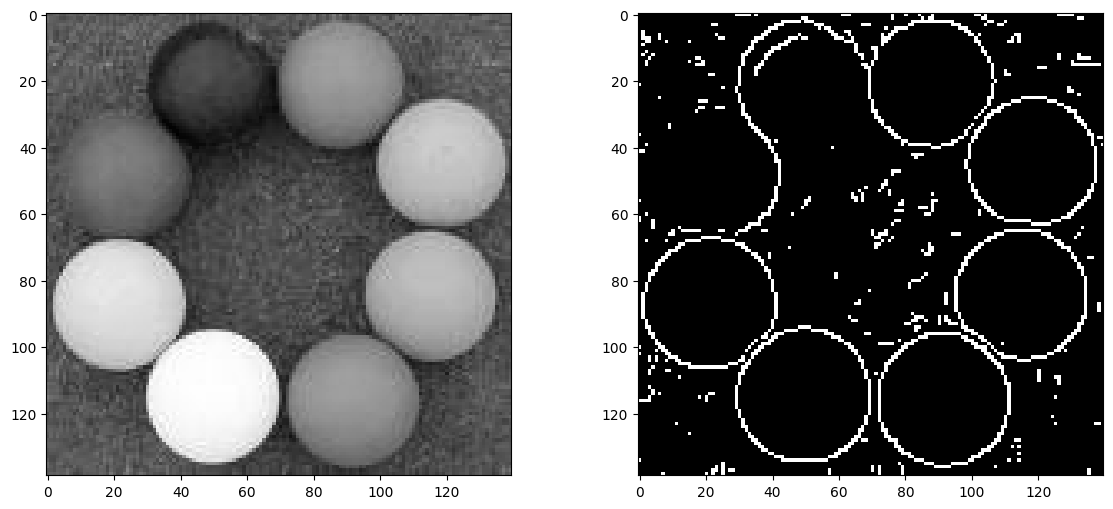

In [ ]:
img1 = read_file(file_name='balls1.tiff') / 255
img1_e, tg_theta1 = edge_detect(img=img1, t_low=9/255, t_high=10/255)
plot_images(img1, img1_e)

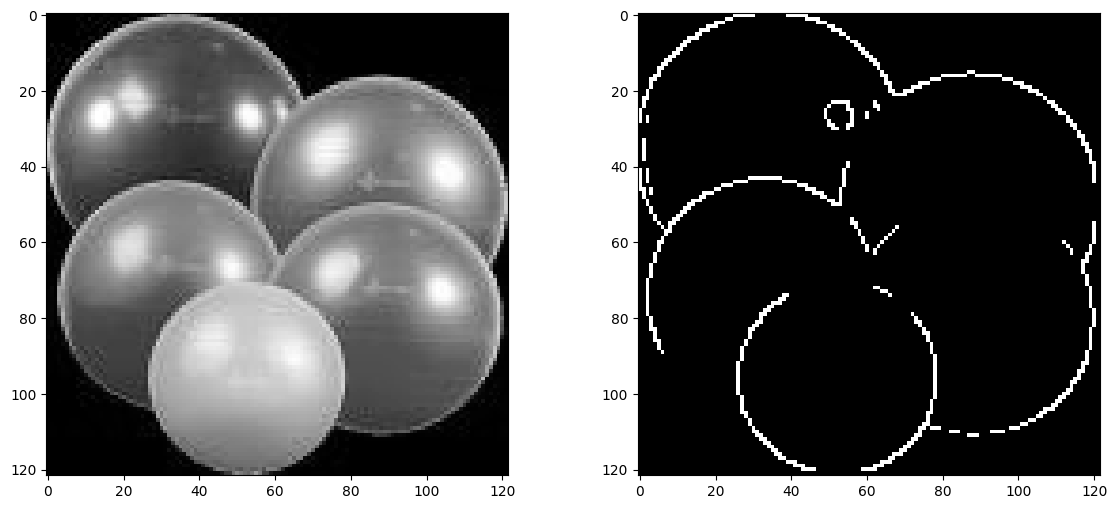

In [ ]:
img4 = read_file(file_name='balls4.tiff') / 255
img4_e, tg_theta = edge_detect(img=img4, t_low=34/255, t_high=36/255)
plot_images(img4, img4_e)

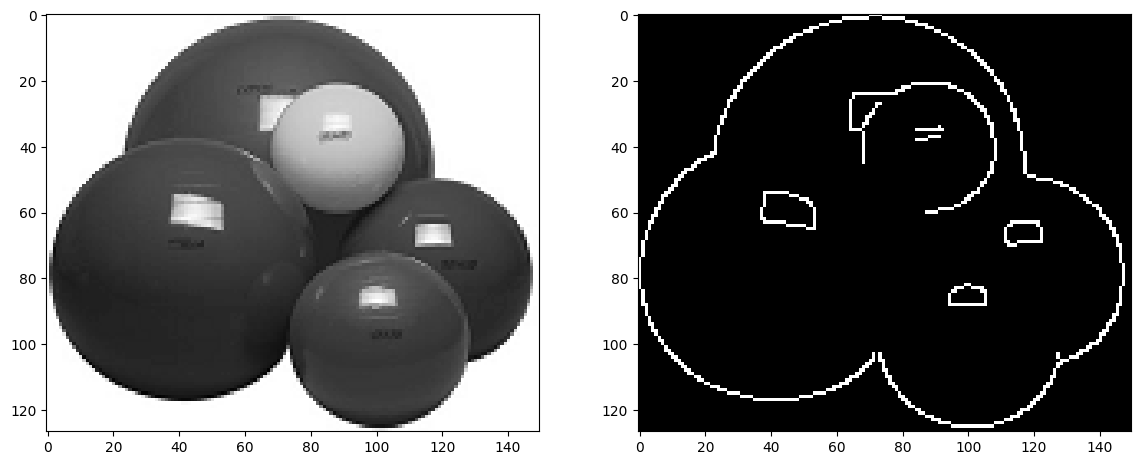

In [ ]:
img5 = read_file(file_name='balls5.tiff') / 255
img5_e, tg_theta5 = edge_detect(img=img5, t_low=22/255, t_high=27/255)
plot_images(img5, img5_e)

## `find_circles`

In [ ]:
def find_circles(img: np.array, t_low: np.float32, t_high: np.float32) -> (np.array, list):
    '''
    This function receives a grayscale image and finds circles in it using Hough
    transform. 
    The function is using the edge_detect function on the given image before 
    performing the Hough transform.
    It also use the tg_theta array to improve the complexity of the algorithm.
    The function also returns a list of the found circles.

    Args:
        img:    image array in float format (range: 0..1) - the source grayscale 
                image.
        t_low:  float format (range: 0..1), the Low threshold value.
        t_high: float format (range: 0..1), the High threshold value.

    Returns:
        img_c:   RGB image array in float format (range: 0..1) which contains 
                    the original image and the marked circles which were found.
        circles: a list - each element represent a circle and contains a list of
                    3 values: origin_x, origin_y, radius
    '''
    ######################################################################
    # TODO: Implement The find_circles algorithm.
    ######################################################################

    # Algorithm: Hough transform for circles. Detect edges, then let each edge
    # pixel vote for centre locations along its gradient direction (tg_theta
    # narrows the search), and keep the strongest, well-covered circles.

    # Step 1: Prepare the image as a 2D float array
    image = np.asarray(img, dtype=np.float32)
    if image.ndim == 3:
        image = image.mean(axis=2)

    # Step 2: Detect edges using Canny (provided thresholds)
    binary_edges, tg = edge_detect(img=image, t_low=t_low, t_high=t_high)

    # Also compute a stricter edge map (higher thresholds) for Hough voting
    strict_edges, _ = edge_detect(img=image, t_low=t_low * 1.8, t_high=t_high * 1.8)
    h, w = image.shape

    # Collect edge pixel coordinates from the strict edge map
    ey, ex = np.nonzero(strict_edges)
    if ex.size == 0:
        print([])
        return image.astype(np.float32), []

    # Step 3: Compute unit gradient direction vectors using tg_theta
    #   These vectors point along the gradient, i.e. toward circle centers
    tg_vals = tg[ey, ex]
    denom = np.sqrt(1.0 + tg_vals ** 2)
    ok = np.isfinite(tg_vals)
    ux = np.where(ok, 1.0 / denom, 0.0).astype(np.float32)  # x-component
    uy = np.where(ok, tg_vals / denom, 1.0).astype(np.float32)  # y-component

    # Helper: fit a circle through a set of points using least-squares
    def _fit_circle(xs, ys):
        A = np.column_stack((xs, ys, np.ones_like(xs)))
        b = -(xs * xs + ys * ys)
        D, E, F = np.linalg.lstsq(A, b, rcond=None)[0]
        cx = -D / 2.0
        cy = -E / 2.0
        radius = np.sqrt(max(cx * cx + cy * cy - F, 0.0))
        return cx, cy, radius

    # Helper: create a binary ring mask for drawing a circle
    def _draw_circle_mask(shape, cx, cy, radius, thickness=1.5):
        yy, xx = np.ogrid[:shape[0], :shape[1]]
        dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
        return (np.abs(dist - radius) <= thickness).astype(np.float32)

    r_max = min(h, w) // 2
    found = []

    # Step 4: Hough voting — for each candidate radius, vote for circle centers
    #   Use tg_theta to restrict votes to the gradient direction (reduces complexity)
    for r in range(12, r_max + 1):
        acc = np.zeros((h, w), dtype=np.int32)

        # Cast votes in both directions along the gradient (sign ambiguity)
        for s in (-1, 1):
            cx_arr = np.rint(ex + s * r * ux).astype(np.intp)
            cy_arr = np.rint(ey + s * r * uy).astype(np.intp)
            inside = (cx_arr >= 0) & (cx_arr < w) & (cy_arr >= 0) & (cy_arr < h)
            np.add.at(acc, (cy_arr[inside], cx_arr[inside]), 1)

        # Adaptive vote threshold based on radius
        thresh = max(5, int(np.ceil(r / 12)))

        # Step 5: Find local maxima in the accumulator as circle candidates
        for row in range(2, h - 2):
            for col in range(2, w - 2):
                v = int(acc[row, col])
                if v < thresh:
                    continue

                # Check if this is a local maximum in a 5x5 neighborhood
                local_patch = acc[row - 2:row + 3, col - 2:col + 3]
                if v != int(np.max(local_patch)):
                    continue

                # Verify: enough edge pixels lie near the candidate circle
                dist_sq = (ex - col) ** 2 + (ey - row) ** 2
                dists = np.sqrt(dist_sq)
                near = np.abs(dists - r) <= 2.0
                n_sup = int(np.sum(near))
                circ_len = 2 * np.pi * r
                if n_sup < max(25, int(0.30 * circ_len)):
                    continue

                # Verify: edge pixels are spread around the full circle (angular coverage)
                ang = (np.rad2deg(np.arctan2(ey[near] - row, ex[near] - col)) + 360.0) % 360.0
                n_bins = len(np.unique((ang // 20).astype(int)))  # 18 bins of 20°
                if n_bins < 12:
                    continue

                # Refine center and radius with least-squares circle fitting
                fc_x, fc_y, fc_r = _fit_circle(
                    ex[near].astype(np.float32), ey[near].astype(np.float32)
                )
                fc_x, fc_y, fc_r = int(np.rint(fc_x)), int(np.rint(fc_y)), int(np.rint(fc_r))

                if 12 <= fc_r <= r_max and 0 <= fc_x < w and 0 <= fc_y < h:
                    found.append((v, n_sup, n_bins, fc_x, fc_y, fc_r))

    # Step 6: Greedy circle selection — pick strongest candidates, suppress duplicates
    found.sort(key=lambda t: (-t[0], -t[1], t[5]))  # Sort by votes descending
    used = np.ones(ex.shape[0], dtype=bool)  # Track which edge pixels are still available
    result = []

    for v, n_sup, n_bins, cx, cy, r in found:
        # Skip if too close to an already-selected circle (duplicate suppression)
        if any(np.hypot(cx - px, cy - py) <= max(12.0, 0.2 * max(r, pr))
               for px, py, pr in result):
            continue

        # Re-count available edge pixels on this circle
        dists = np.hypot(ex - cx, ey - cy)
        on_circ = (np.abs(dists - r) <= 2.5) & used
        cnt = int(np.sum(on_circ))
        circ_len = 2 * np.pi * r
        if cnt < max(25, int(0.22 * circ_len)):
            continue

        # Verify angular coverage of remaining edge pixels
        ang = (np.rad2deg(np.arctan2(ey[on_circ] - cy, ex[on_circ] - cx)) + 360.0) % 360.0
        if (len(np.unique((ang // 20).astype(int))) if cnt else 0) < 9:
            continue

        result.append((cx, cy, r))
        used[np.abs(dists - r) <= 4.0] = False  # Mark these edge pixels as consumed

    result.sort(key=lambda c: (c[0], c[1]))  # Sort by position for consistent output

    # Step 7: Draw detected circles onto an output image
    img_c = np.zeros((h, w), dtype=np.float32)
    for cx, cy, r in result:
        img_c += _draw_circle_mask((h, w), cx, cy, r, thickness=0.5)
    img_c = np.clip(img_c, 0.0, 1.0)

    circles = [[int(cx), int(cy), int(r)] for cx, cy, r in result]
    print(circles)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_c, circles

[[41, 78, 40], [70, 49, 48], [88, 39, 20], [101, 99, 27], [118, 79, 29]]
[[41, 78, 40], [70, 49, 48], [88, 39, 20], [101, 99, 27], [118, 79, 29]]


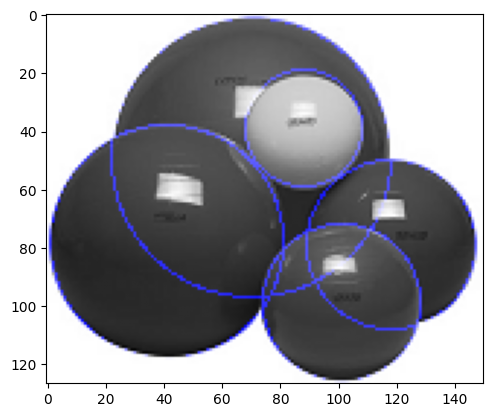

In [ ]:
img = read_file(file_name='balls5.tiff') / 255
img_c, circles = find_circles(img=img, t_low=9/255, t_high=10/255)

img_rgb = np.dstack((img, img, img))
img_rgb[:,:,2] += img_c
img_rgb = img_rgb.clip(0,1)
plt.imshow(img_rgb);
print(circles)

C:\Users\IMOE001\AppData\Local\Temp\ipykernel_28992\1423581515.py:45: RuntimeWarning: invalid value encountered in divide
  uy = np.where(ok, tg_vals / denom, 1.0).astype(np.float32)


[[33, 74, 31], [36, 37, 35], [52, 96, 26], [88, 49, 33], [89, 80, 31]]
[[33, 74, 31], [36, 37, 35], [52, 96, 26], [88, 49, 33], [89, 80, 31]]


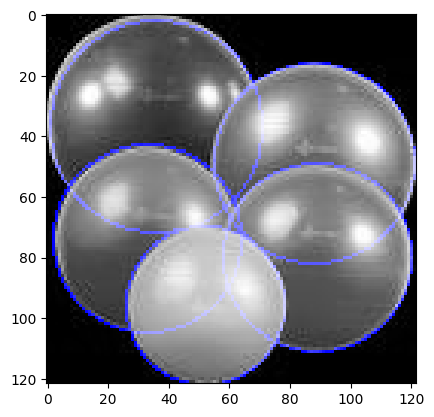

In [ ]:
img = read_file(file_name='balls4.tiff') / 255
img_c, circles = find_circles(img=img, t_low=9/255, t_high=10/255)

img_rgb = np.dstack((img, img, img))
img_rgb[:,:,2] += img_c
img_rgb = img_rgb.clip(0,1)
plt.imshow(img_rgb);
print(circles)